# XGBoost

#### Imports

In [9]:
%load_ext autoreload
%autoreload 2

import sys
import os
sys.path.append(os.path.abspath('..'))

import pandas as pd

from src.xgb_experiment import XGBExperiment
from src.utils import evaluate_model, save_results

## Experimento 1: Conjunto com todas as Features

In [10]:
import pandas as pd
caminho = '../'

X_test_exp1 = pd.read_csv(caminho + 'database/processed/splitted/X_test.csv')
X_train_exp1 = pd.read_csv(caminho + 'database/processed/splitted/X_train.csv')
y_test_exp1 = pd.read_csv(caminho + 'database/processed/splitted/y_test.csv').squeeze()
y_train_exp1 = pd.read_csv(caminho + 'database/processed/splitted/y_train.csv').squeeze()

### XGboost - Default

In [11]:
import xgboost as xgb

xgboost_exp1 = xgb.XGBClassifier(n_estimators=100, random_state=14)
xgboost_exp1.fit(X_train_exp1, y_train_exp1)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


=== Métricas xgb_def_exp1  ===
    Acurácia: 0.7838
    Precisão: 0.7538
    Recall:   0.7461
    F1-Score: 0.7496
    MCC:      0.4999
    AUC:      0.8459


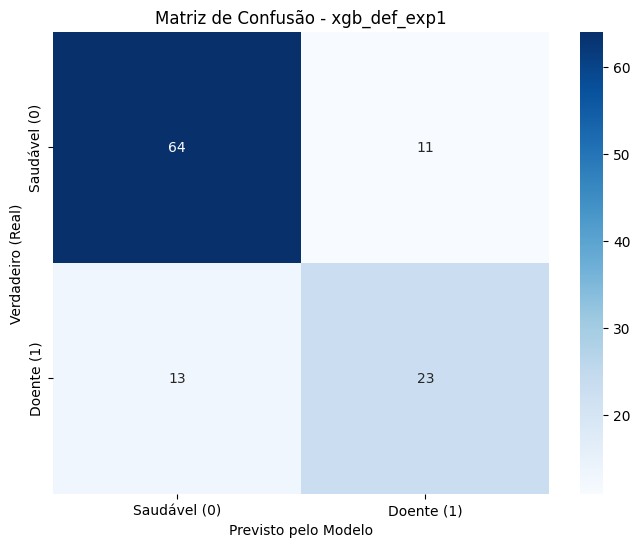

In [12]:
# Avaliar modelo
y_pred_def_exp1 = xgboost_exp1.predict(X_test_exp1)
y_prob_def_exp1 = xgboost_exp1.predict_proba(X_test_exp1)[:, 1]

evaluate_model(y_test_exp1, y_pred_def_exp1, y_prob_def_exp1, 'xgb_def_exp1')
save_results(y_pred_def_exp1, y_prob_def_exp1, 'xgb_def_exp1', caminho)

### XGBoost - Melhorado

In [13]:
# Criar o experimento
experimento_1 = XGBExperiment(X_train_exp1, y_train_exp1, 'xgb_otz_exp1', caminho)
experimento_1.tune_and_fit(n_trials=50)
best_xgb = experimento_1.best_model

[I 2026-08-16 15:08:26,855] A new study created in memory with name: no-name-ef17b640-6319-4ba3-aa2c-0a0f8b77b6ce


Iniciando otimização do cenário xgb_otz_exp1.


Best trial: 0. Best value: 0.775415:   2%|▏         | 1/50 [00:00<00:31,  1.57it/s]

[I 2026-08-16 15:08:27,498] Trial 0 finished with value: 0.7754147812971341 and parameters: {'n_estimators': 105, 'max_depth': 3, 'learning_rate': 0.052332894323888664, 'subsample': 0.8813356162297469, 'colsample_bytree': 0.6488431225407512, 'gamma': 4.411911691609733}. Best is trial 0 with value: 0.7754147812971341.


Best trial: 1. Best value: 0.779261:   4%|▍         | 2/50 [00:01<00:31,  1.54it/s]

[I 2026-08-16 15:08:28,154] Trial 1 finished with value: 0.779260935143288 and parameters: {'n_estimators': 251, 'max_depth': 7, 'learning_rate': 0.0814958587145931, 'subsample': 0.8328454704112054, 'colsample_bytree': 0.5941896827758721, 'gamma': 3.9057657558126597}. Best is trial 1 with value: 0.779260935143288.


Best trial: 2. Best value: 0.794721:   6%|▌         | 3/50 [00:01<00:29,  1.62it/s]

[I 2026-08-16 15:08:28,736] Trial 2 finished with value: 0.7947209653092007 and parameters: {'n_estimators': 118, 'max_depth': 3, 'learning_rate': 0.060230564978986156, 'subsample': 0.5191356233995414, 'colsample_bytree': 0.7055042485711164, 'gamma': 1.0086776902518102}. Best is trial 2 with value: 0.7947209653092007.


Best trial: 3. Best value: 0.806335:   8%|▊         | 4/50 [00:02<00:32,  1.42it/s]

[I 2026-08-16 15:08:29,569] Trial 3 finished with value: 0.8063348416289593 and parameters: {'n_estimators': 249, 'max_depth': 9, 'learning_rate': 0.023799720683596037, 'subsample': 0.5263564000703123, 'colsample_bytree': 0.9333219182583883, 'gamma': 0.19572235126958437}. Best is trial 3 with value: 0.8063348416289593.


Best trial: 3. Best value: 0.806335:  10%|█         | 5/50 [00:03<00:27,  1.66it/s]

[I 2026-08-16 15:08:29,993] Trial 4 finished with value: 0.7831070889894418 and parameters: {'n_estimators': 270, 'max_depth': 10, 'learning_rate': 0.01971676007662733, 'subsample': 0.9250445414681367, 'colsample_bytree': 0.9154574320904311, 'gamma': 4.053060688255792}. Best is trial 3 with value: 0.8063348416289593.


Best trial: 3. Best value: 0.806335:  12%|█▏        | 6/50 [00:03<00:24,  1.82it/s]

[I 2026-08-16 15:08:30,437] Trial 5 finished with value: 0.7716440422322774 and parameters: {'n_estimators': 104, 'max_depth': 3, 'learning_rate': 0.03198862523416551, 'subsample': 0.713936017141389, 'colsample_bytree': 0.6155133236919635, 'gamma': 1.014304497282077}. Best is trial 3 with value: 0.8063348416289593.


Best trial: 3. Best value: 0.806335:  14%|█▍        | 7/50 [00:03<00:18,  2.28it/s]

[I 2026-08-16 15:08:30,649] Trial 6 finished with value: 0.7677978883861236 and parameters: {'n_estimators': 83, 'max_depth': 10, 'learning_rate': 0.2933431158206953, 'subsample': 0.8951187321725509, 'colsample_bytree': 0.7454676891802008, 'gamma': 0.846689637783789}. Best is trial 3 with value: 0.8063348416289593.


Best trial: 3. Best value: 0.806335:  16%|█▌        | 8/50 [00:04<00:20,  2.05it/s]

[I 2026-08-16 15:08:31,241] Trial 7 finished with value: 0.7908748114630468 and parameters: {'n_estimators': 293, 'max_depth': 10, 'learning_rate': 0.03727203878675482, 'subsample': 0.7813479203928883, 'colsample_bytree': 0.6242654310805844, 'gamma': 1.04499703655347}. Best is trial 3 with value: 0.8063348416289593.


Best trial: 3. Best value: 0.806335:  18%|█▊        | 9/50 [00:04<00:20,  1.98it/s]

[I 2026-08-16 15:08:31,786] Trial 8 finished with value: 0.7987179487179487 and parameters: {'n_estimators': 255, 'max_depth': 6, 'learning_rate': 0.07884869239006435, 'subsample': 0.8697754074431645, 'colsample_bytree': 0.6268186957066034, 'gamma': 1.377828655663138}. Best is trial 3 with value: 0.8063348416289593.


Best trial: 3. Best value: 0.806335:  20%|██        | 10/50 [00:05<00:21,  1.84it/s]

[I 2026-08-16 15:08:32,413] Trial 9 finished with value: 0.7947209653092007 and parameters: {'n_estimators': 275, 'max_depth': 9, 'learning_rate': 0.02829167981938271, 'subsample': 0.5136910409880003, 'colsample_bytree': 0.9591739926620959, 'gamma': 3.6370597710617023}. Best is trial 3 with value: 0.8063348416289593.


Best trial: 3. Best value: 0.806335:  22%|██▏       | 11/50 [00:06<00:22,  1.75it/s]

[I 2026-08-16 15:08:33,050] Trial 10 finished with value: 0.783182503770739 and parameters: {'n_estimators': 190, 'max_depth': 7, 'learning_rate': 0.010184734574075677, 'subsample': 0.6690125193401458, 'colsample_bytree': 0.8488009924026877, 'gamma': 2.6052314243107935}. Best is trial 3 with value: 0.8063348416289593.


Best trial: 3. Best value: 0.806335:  24%|██▍       | 12/50 [00:06<00:21,  1.77it/s]

[I 2026-08-16 15:08:33,601] Trial 11 finished with value: 0.7638763197586727 and parameters: {'n_estimators': 223, 'max_depth': 5, 'learning_rate': 0.16651528036974722, 'subsample': 0.6251245710049077, 'colsample_bytree': 0.8242338555259996, 'gamma': 0.10756268564374286}. Best is trial 3 with value: 0.8063348416289593.


Best trial: 3. Best value: 0.806335:  26%|██▌       | 13/50 [00:07<00:18,  1.99it/s]

[I 2026-08-16 15:08:33,962] Trial 12 finished with value: 0.8026395173453997 and parameters: {'n_estimators': 208, 'max_depth': 5, 'learning_rate': 0.11049873078057293, 'subsample': 0.7931152705190679, 'colsample_bytree': 0.8170926947096262, 'gamma': 2.0247056185593904}. Best is trial 3 with value: 0.8063348416289593.


Best trial: 3. Best value: 0.806335:  28%|██▊       | 14/50 [00:07<00:18,  1.99it/s]

[I 2026-08-16 15:08:34,458] Trial 13 finished with value: 0.7834087481146305 and parameters: {'n_estimators': 164, 'max_depth': 5, 'learning_rate': 0.13667838179192265, 'subsample': 0.9959595237210426, 'colsample_bytree': 0.9928063182464186, 'gamma': 2.270547440497635}. Best is trial 3 with value: 0.8063348416289593.


Best trial: 3. Best value: 0.806335:  30%|███       | 15/50 [00:08<00:18,  1.85it/s]

[I 2026-08-16 15:08:35,091] Trial 14 finished with value: 0.783182503770739 and parameters: {'n_estimators': 206, 'max_depth': 8, 'learning_rate': 0.013211661837311817, 'subsample': 0.5979384441593234, 'colsample_bytree': 0.821559450744346, 'gamma': 2.3534343564145117}. Best is trial 3 with value: 0.8063348416289593.


Best trial: 3. Best value: 0.806335:  32%|███▏      | 16/50 [00:08<00:19,  1.76it/s]

[I 2026-08-16 15:08:35,719] Trial 15 finished with value: 0.7637254901960784 and parameters: {'n_estimators': 156, 'max_depth': 5, 'learning_rate': 0.12440805940141166, 'subsample': 0.7801434226981873, 'colsample_bytree': 0.5151247700136153, 'gamma': 0.0020507328989598506}. Best is trial 3 with value: 0.8063348416289593.


Best trial: 3. Best value: 0.806335:  34%|███▍      | 17/50 [00:09<00:21,  1.56it/s]

[I 2026-08-16 15:08:36,534] Trial 16 finished with value: 0.794947209653092 and parameters: {'n_estimators': 228, 'max_depth': 8, 'learning_rate': 0.0205921683355275, 'subsample': 0.5798544868828677, 'colsample_bytree': 0.8996261595381715, 'gamma': 1.7911419576939385}. Best is trial 3 with value: 0.8063348416289593.


Best trial: 3. Best value: 0.806335:  36%|███▌      | 18/50 [00:09<00:16,  1.98it/s]

[I 2026-08-16 15:08:36,721] Trial 17 finished with value: 0.7950980392156863 and parameters: {'n_estimators': 50, 'max_depth': 6, 'learning_rate': 0.24150201738667318, 'subsample': 0.7269857878013707, 'colsample_bytree': 0.8829990970390206, 'gamma': 3.040114447806374}. Best is trial 3 with value: 0.8063348416289593.


Best trial: 3. Best value: 0.806335:  38%|███▊      | 19/50 [00:10<00:14,  2.12it/s]

[I 2026-08-16 15:08:37,116] Trial 18 finished with value: 0.7833333333333333 and parameters: {'n_estimators': 150, 'max_depth': 4, 'learning_rate': 0.047323948049017246, 'subsample': 0.6717407827500756, 'colsample_bytree': 0.7672255154765961, 'gamma': 3.187699661837511}. Best is trial 3 with value: 0.8063348416289593.


Best trial: 3. Best value: 0.806335:  40%|████      | 20/50 [00:10<00:14,  2.07it/s]

[I 2026-08-16 15:08:37,624] Trial 19 finished with value: 0.7754901960784314 and parameters: {'n_estimators': 231, 'max_depth': 8, 'learning_rate': 0.09312944673245255, 'subsample': 0.8090082212705689, 'colsample_bytree': 0.7819332417716611, 'gamma': 4.880318992767075}. Best is trial 3 with value: 0.8063348416289593.


Best trial: 3. Best value: 0.806335:  42%|████▏     | 21/50 [00:11<00:15,  1.90it/s]

[I 2026-08-16 15:08:38,248] Trial 20 finished with value: 0.7909502262443437 and parameters: {'n_estimators': 179, 'max_depth': 9, 'learning_rate': 0.021073092995185984, 'subsample': 0.9635127498774234, 'colsample_bytree': 0.9470351248605979, 'gamma': 0.5168525192038919}. Best is trial 3 with value: 0.8063348416289593.


Best trial: 3. Best value: 0.806335:  44%|████▍     | 22/50 [00:11<00:15,  1.86it/s]

[I 2026-08-16 15:08:38,819] Trial 21 finished with value: 0.7986425339366516 and parameters: {'n_estimators': 253, 'max_depth': 6, 'learning_rate': 0.08822391203105234, 'subsample': 0.8490277801019349, 'colsample_bytree': 0.7358136854069565, 'gamma': 1.6544471077510858}. Best is trial 3 with value: 0.8063348416289593.


Best trial: 3. Best value: 0.806335:  46%|████▌     | 23/50 [00:12<00:15,  1.76it/s]

[I 2026-08-16 15:08:39,456] Trial 22 finished with value: 0.7986425339366516 and parameters: {'n_estimators': 207, 'max_depth': 6, 'learning_rate': 0.06168315199093857, 'subsample': 0.8652393027921874, 'colsample_bytree': 0.5293946509701277, 'gamma': 1.6634201271246336}. Best is trial 3 with value: 0.8063348416289593.


Best trial: 3. Best value: 0.806335:  48%|████▊     | 24/50 [00:13<00:14,  1.80it/s]

[I 2026-08-16 15:08:39,982] Trial 23 finished with value: 0.7986425339366516 and parameters: {'n_estimators': 250, 'max_depth': 4, 'learning_rate': 0.1795435908101718, 'subsample': 0.7548736458737189, 'colsample_bytree': 0.7090132524234194, 'gamma': 1.4681779426748425}. Best is trial 3 with value: 0.8063348416289593.


Best trial: 3. Best value: 0.806335:  50%|█████     | 25/50 [00:13<00:15,  1.61it/s]

[I 2026-08-16 15:08:40,761] Trial 24 finished with value: 0.791025641025641 and parameters: {'n_estimators': 277, 'max_depth': 7, 'learning_rate': 0.11152643756404178, 'subsample': 0.9263292745249891, 'colsample_bytree': 0.5660704510958603, 'gamma': 0.39187537257680993}. Best is trial 3 with value: 0.8063348416289593.


Best trial: 3. Best value: 0.806335:  52%|█████▏    | 26/50 [00:14<00:14,  1.60it/s]

[I 2026-08-16 15:08:41,386] Trial 25 finished with value: 0.7987933634992459 and parameters: {'n_estimators': 299, 'max_depth': 4, 'learning_rate': 0.0720941746465533, 'subsample': 0.691430537888613, 'colsample_bytree': 0.6713310792377394, 'gamma': 2.0160099142724626}. Best is trial 3 with value: 0.8063348416289593.


Best trial: 3. Best value: 0.806335:  54%|█████▍    | 27/50 [00:15<00:14,  1.60it/s]

[I 2026-08-16 15:08:42,015] Trial 26 finished with value: 0.7987179487179488 and parameters: {'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.04096917362594802, 'subsample': 0.552995867474791, 'colsample_bytree': 0.6946620578304155, 'gamma': 2.7622489771587495}. Best is trial 3 with value: 0.8063348416289593.


Best trial: 27. Best value: 0.80641:  56%|█████▌    | 28/50 [00:15<00:13,  1.65it/s]

[I 2026-08-16 15:08:42,571] Trial 27 finished with value: 0.8064102564102564 and parameters: {'n_estimators': 285, 'max_depth': 4, 'learning_rate': 0.06885352808959534, 'subsample': 0.6637040617980927, 'colsample_bytree': 0.8551836792891558, 'gamma': 2.066434603133793}. Best is trial 27 with value: 0.8064102564102564.


Best trial: 27. Best value: 0.80641:  58%|█████▊    | 29/50 [00:16<00:13,  1.56it/s]

[I 2026-08-16 15:08:43,297] Trial 28 finished with value: 0.7869532428355959 and parameters: {'n_estimators': 207, 'max_depth': 5, 'learning_rate': 0.014499658046339806, 'subsample': 0.6194977963629371, 'colsample_bytree': 0.8691470909267353, 'gamma': 2.0347565610079035}. Best is trial 27 with value: 0.8064102564102564.


Best trial: 27. Best value: 0.80641:  60%|██████    | 30/50 [00:16<00:11,  1.71it/s]

[I 2026-08-16 15:08:43,753] Trial 29 finished with value: 0.8064102564102564 and parameters: {'n_estimators': 235, 'max_depth': 3, 'learning_rate': 0.05360881133175972, 'subsample': 0.5549066978176669, 'colsample_bytree': 0.7997377136076377, 'gamma': 3.364657565594319}. Best is trial 27 with value: 0.8064102564102564.


Best trial: 27. Best value: 0.80641:  62%|██████▏   | 31/50 [00:17<00:10,  1.79it/s]

[I 2026-08-16 15:08:44,249] Trial 30 finished with value: 0.7871040723981899 and parameters: {'n_estimators': 236, 'max_depth': 3, 'learning_rate': 0.029288369207837138, 'subsample': 0.5564060699676583, 'colsample_bytree': 0.9216152396074527, 'gamma': 3.3741567022511294}. Best is trial 27 with value: 0.8064102564102564.


Best trial: 27. Best value: 0.80641:  64%|██████▍   | 32/50 [00:17<00:09,  1.85it/s]

[I 2026-08-16 15:08:44,751] Trial 31 finished with value: 0.7948717948717949 and parameters: {'n_estimators': 280, 'max_depth': 3, 'learning_rate': 0.049501240683962465, 'subsample': 0.6391453502056115, 'colsample_bytree': 0.8074119915038498, 'gamma': 2.8785369389146487}. Best is trial 27 with value: 0.8064102564102564.


Best trial: 27. Best value: 0.80641:  66%|██████▌   | 33/50 [00:18<00:08,  1.96it/s]

[I 2026-08-16 15:08:45,185] Trial 32 finished with value: 0.7987179487179487 and parameters: {'n_estimators': 264, 'max_depth': 4, 'learning_rate': 0.10381733090231728, 'subsample': 0.5544399480483858, 'colsample_bytree': 0.8513567914551933, 'gamma': 4.452546849923327}. Best is trial 27 with value: 0.8064102564102564.


Best trial: 27. Best value: 0.80641:  68%|██████▊   | 34/50 [00:18<00:07,  2.05it/s]

[I 2026-08-16 15:08:45,626] Trial 33 finished with value: 0.7754147812971341 and parameters: {'n_estimators': 242, 'max_depth': 3, 'learning_rate': 0.0654505554121069, 'subsample': 0.5309224464178488, 'colsample_bytree': 0.8006820576090009, 'gamma': 3.554458733268949}. Best is trial 27 with value: 0.8064102564102564.


Best trial: 27. Best value: 0.80641:  70%|███████   | 35/50 [00:19<00:06,  2.16it/s]

[I 2026-08-16 15:08:46,030] Trial 34 finished with value: 0.790950226244344 and parameters: {'n_estimators': 213, 'max_depth': 5, 'learning_rate': 0.14120920946865087, 'subsample': 0.5023533235688832, 'colsample_bytree': 0.8489747229810202, 'gamma': 2.5202726536657516}. Best is trial 27 with value: 0.8064102564102564.


Best trial: 27. Best value: 0.80641:  72%|███████▏  | 36/50 [00:19<00:06,  2.12it/s]

[I 2026-08-16 15:08:46,521] Trial 35 finished with value: 0.779260935143288 and parameters: {'n_estimators': 192, 'max_depth': 4, 'learning_rate': 0.0486532016964791, 'subsample': 0.5958066648773166, 'colsample_bytree': 0.9524032503582869, 'gamma': 4.269870630074452}. Best is trial 27 with value: 0.8064102564102564.


Best trial: 27. Best value: 0.80641:  74%|███████▍  | 37/50 [00:20<00:06,  2.03it/s]

[I 2026-08-16 15:08:47,061] Trial 36 finished with value: 0.7832579185520362 and parameters: {'n_estimators': 268, 'max_depth': 3, 'learning_rate': 0.025974818282687485, 'subsample': 0.6538682350724354, 'colsample_bytree': 0.9925283077720225, 'gamma': 3.749873468351094}. Best is trial 27 with value: 0.8064102564102564.


Best trial: 27. Best value: 0.80641:  76%|███████▌  | 38/50 [00:20<00:06,  1.83it/s]

[I 2026-08-16 15:08:47,730] Trial 37 finished with value: 0.7986425339366516 and parameters: {'n_estimators': 284, 'max_depth': 9, 'learning_rate': 0.0362212339692182, 'subsample': 0.8132558879926556, 'colsample_bytree': 0.9031148616659072, 'gamma': 1.220673499118964}. Best is trial 27 with value: 0.8064102564102564.


Best trial: 27. Best value: 0.80641:  78%|███████▊  | 39/50 [00:21<00:05,  2.03it/s]

[I 2026-08-16 15:08:48,101] Trial 38 finished with value: 0.7987179487179488 and parameters: {'n_estimators': 141, 'max_depth': 3, 'learning_rate': 0.07559757991705127, 'subsample': 0.715614943055951, 'colsample_bytree': 0.7787224964987558, 'gamma': 1.9597008032615801}. Best is trial 27 with value: 0.8064102564102564.


Best trial: 27. Best value: 0.80641:  80%|████████  | 40/50 [00:21<00:05,  1.86it/s]

[I 2026-08-16 15:08:48,746] Trial 39 finished with value: 0.7986425339366516 and parameters: {'n_estimators': 244, 'max_depth': 4, 'learning_rate': 0.05808652204398655, 'subsample': 0.5385236052413197, 'colsample_bytree': 0.9316214096642368, 'gamma': 0.6027672634545513}. Best is trial 27 with value: 0.8064102564102564.


Best trial: 27. Best value: 0.80641:  82%|████████▏ | 41/50 [00:22<00:04,  2.03it/s]

[I 2026-08-16 15:08:49,128] Trial 40 finished with value: 0.8025641025641026 and parameters: {'n_estimators': 219, 'max_depth': 7, 'learning_rate': 0.1975002002113821, 'subsample': 0.5770426205911546, 'colsample_bytree': 0.7500969356784865, 'gamma': 4.085651263882168}. Best is trial 27 with value: 0.8064102564102564.


Best trial: 27. Best value: 0.80641:  84%|████████▍ | 42/50 [00:22<00:03,  2.16it/s]

[I 2026-08-16 15:08:49,524] Trial 41 finished with value: 0.7986425339366516 and parameters: {'n_estimators': 223, 'max_depth': 7, 'learning_rate': 0.18667603939483585, 'subsample': 0.5780468735031443, 'colsample_bytree': 0.7343875125931196, 'gamma': 4.092209275080067}. Best is trial 27 with value: 0.8064102564102564.


Best trial: 42. Best value: 0.810332:  86%|████████▌ | 43/50 [00:23<00:02,  2.34it/s]

[I 2026-08-16 15:08:49,873] Trial 42 finished with value: 0.8103318250377074 and parameters: {'n_estimators': 190, 'max_depth': 8, 'learning_rate': 0.22989191457689875, 'subsample': 0.6071081753191776, 'colsample_bytree': 0.7633590650930177, 'gamma': 4.793298935182456}. Best is trial 42 with value: 0.8103318250377074.


Best trial: 42. Best value: 0.810332:  88%|████████▊ | 44/50 [00:23<00:02,  2.42it/s]

[I 2026-08-16 15:08:50,245] Trial 43 finished with value: 0.8026395173453997 and parameters: {'n_estimators': 192, 'max_depth': 9, 'learning_rate': 0.15311924303352342, 'subsample': 0.6110330718196744, 'colsample_bytree': 0.8336538267914533, 'gamma': 4.948825803453346}. Best is trial 42 with value: 0.8103318250377074.


Best trial: 42. Best value: 0.810332:  90%|█████████ | 45/50 [00:23<00:02,  2.36it/s]

[I 2026-08-16 15:08:50,699] Trial 44 finished with value: 0.7989441930618402 and parameters: {'n_estimators': 261, 'max_depth': 10, 'learning_rate': 0.255309254850121, 'subsample': 0.6926598582402766, 'colsample_bytree': 0.873484108958245, 'gamma': 4.519661762879367}. Best is trial 42 with value: 0.8103318250377074.


Best trial: 42. Best value: 0.810332:  92%|█████████▏| 46/50 [00:24<00:01,  2.45it/s]

[I 2026-08-16 15:08:51,070] Trial 45 finished with value: 0.7754147812971341 and parameters: {'n_estimators': 175, 'max_depth': 8, 'learning_rate': 0.2925838142231649, 'subsample': 0.7560350674086642, 'colsample_bytree': 0.7981986162494544, 'gamma': 0.835985595007526}. Best is trial 42 with value: 0.8103318250377074.


Best trial: 46. Best value: 0.8181:  94%|█████████▍| 47/50 [00:24<00:01,  2.42it/s]  

[I 2026-08-16 15:08:51,497] Trial 46 finished with value: 0.8180995475113122 and parameters: {'n_estimators': 126, 'max_depth': 9, 'learning_rate': 0.10634874953547326, 'subsample': 0.5233827210224342, 'colsample_bytree': 0.7591207139835112, 'gamma': 2.22226977250365}. Best is trial 46 with value: 0.8180995475113122.


Best trial: 46. Best value: 0.8181:  96%|█████████▌| 48/50 [00:24<00:00,  2.61it/s]

[I 2026-08-16 15:08:51,810] Trial 47 finished with value: 0.7947209653092007 and parameters: {'n_estimators': 90, 'max_depth': 9, 'learning_rate': 0.01719100558385738, 'subsample': 0.5195251936583719, 'colsample_bytree': 0.7159939714988384, 'gamma': 3.33119296336462}. Best is trial 46 with value: 0.8180995475113122.


Best trial: 46. Best value: 0.8181:  98%|█████████▊| 49/50 [00:25<00:00,  2.66it/s]

[I 2026-08-16 15:08:52,169] Trial 48 finished with value: 0.7986425339366516 and parameters: {'n_estimators': 113, 'max_depth': 10, 'learning_rate': 0.03647285313082824, 'subsample': 0.5018935889435657, 'colsample_bytree': 0.7662830194135657, 'gamma': 2.299846192170708}. Best is trial 46 with value: 0.8180995475113122.


Best trial: 46. Best value: 0.8181: 100%|██████████| 50/50 [00:25<00:00,  1.93it/s]

[I 2026-08-16 15:08:52,771] Trial 49 finished with value: 0.8064102564102564 and parameters: {'n_estimators': 285, 'max_depth': 9, 'learning_rate': 0.025314994639272444, 'subsample': 0.5377428359216082, 'colsample_bytree': 0.6785094501349967, 'gamma': 2.711706417174125}. Best is trial 46 with value: 0.8180995475113122.
Melhor pontuação (CV): 0.8181
Melhores parâmetros:
{'n_estimators': 126, 'max_depth': 9, 'learning_rate': 0.10634874953547326, 'subsample': 0.5233827210224342, 'colsample_bytree': 0.7591207139835112, 'gamma': 2.22226977250365}


In [14]:
import optuna
fig = optuna.visualization.plot_param_importances(experimento_1.study)
fig.show()

fig = optuna.visualization.plot_optimization_history(experimento_1.study)
fig.show()

=== IMPORTÂNCIA DAS FEATURES (XGBoost) ===
      feature  importance
  eosinophils      0.1072
  lymphocytes      0.0819
    platelets      0.0658
          mcv      0.0545
    basophils      0.0522
          mpv      0.0519
 lymphocytesP      0.0480
 eosinophilsP      0.0467
   leukocytes      0.0448
         rdwP      0.0442
         mchc      0.0432
redbloodcells      0.0428
  neutrophils      0.0425
          mch      0.0423
 neutrophilsP      0.0419
  hematocritP      0.0407
    monocytes      0.0395
   monocytesP      0.0388
   basophilsP      0.0364
   hemoglobin      0.0346


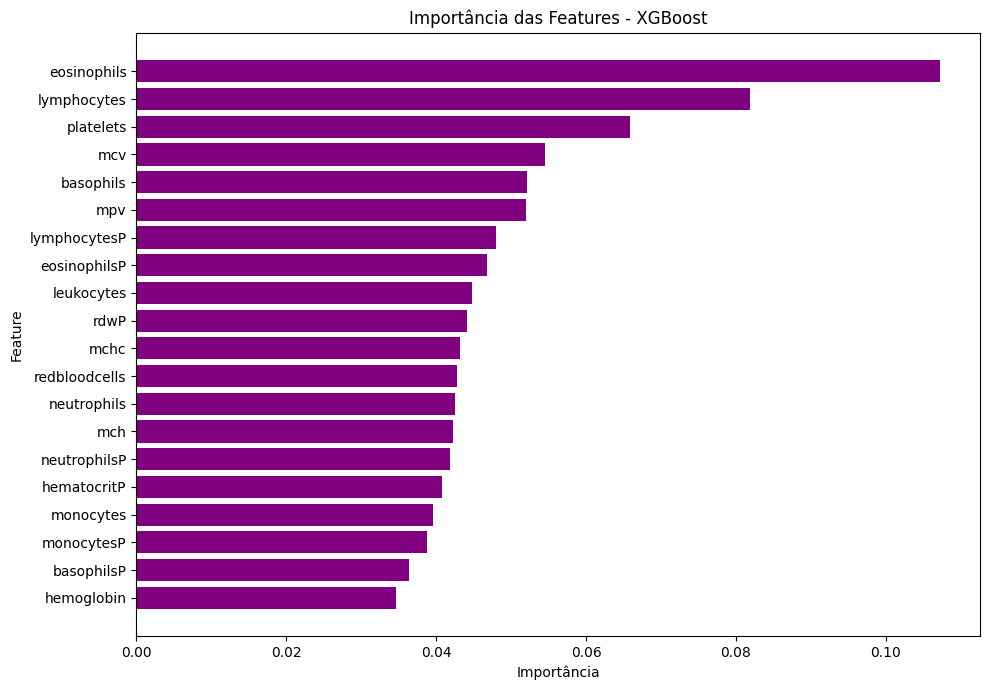

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# Importância das features do XGBoost
feature_importance = pd.DataFrame({
    'feature': X_train_exp1.columns,
    'importance': best_xgb.feature_importances_
}).sort_values('importance', ascending=False)

print('=== IMPORTÂNCIA DAS FEATURES (XGBoost) ===')
print(feature_importance.round(4).to_string(index=False))

plt.figure(figsize=(10, max(6, 0.35 * len(feature_importance))))
plt.barh(feature_importance['feature'], feature_importance['importance'], color='purple')
plt.title('Importância das Features - XGBoost')
plt.xlabel('Importância')
plt.ylabel('Feature')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

=== Métricas xgb_otz_exp1  ===
    Acurácia: 0.8288
    Precisão: 0.8121
    Recall:   0.7867
    F1-Score: 0.7969
    MCC:      0.5982
    AUC:      0.8496


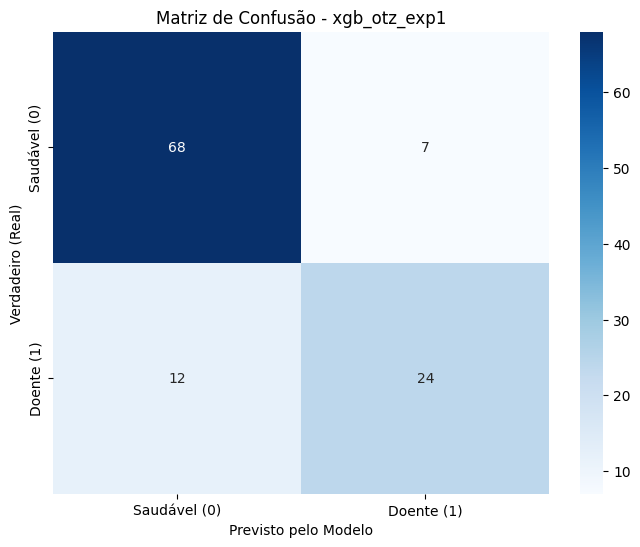

In [16]:
# Avaliar resultados e salvar
y_pred_otz_exp1 = experimento_1.best_model.predict(X_test_exp1)
y_prob_otz_exp1 = experimento_1.best_model.predict_proba(X_test_exp1)[:, 1]

evaluate_model(y_test_exp1, y_pred_otz_exp1, y_prob_otz_exp1, 'xgb_otz_exp1')
save_results(y_pred_otz_exp1, y_prob_otz_exp1, 'xgb_otz_exp1', caminho)